In [524]:
import pandas as pd

df = pd.read_csv("/home/yash/Downloads/house_price_prediction_dataset_3000_fixed.csv")
df = df.drop(columns = ["age_years"])

In [525]:
df.head()

,area_sqft,bedrooms,bathrooms,floors,garage,distance_from_city_km,condition,location,has_garden,has_pool,parking,year_built,price_inr
0,3674,6,4.0,2.0,3.0,22.3,4.0,Suburban,1,1,1,2004,56707000
1,4007,6,4.0,1.5,0.0,20.0,5.0,NaN,0,0,0,2005,55874000
2,1360,2,1.0,2.5,2.0,24.9,NaN,Urban,0,0,1,2023,21074000
3,1794,2,2.0,1.0,2.0,20.7,3.0,Urban,1,0,0,1993,24797000
4,1630,4,3.0,1.0,3.0,16.3,3.0,Suburban,0,1,1,2021,28868000


In [526]:
df.select_dtypes(include='number').corr()["price_inr"]

area_sqft                0.985930
bedrooms                 0.899899
bathrooms                0.823199
floors                  -0.008070
garage                   0.036943
distance_from_city_km   -0.046979
condition                0.056831
has_garden               0.013253
has_pool                 0.024720
parking                 -0.018002
year_built               0.060385
price_inr                1.000000
Name: price_inr, dtype: float64

In [527]:
df.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                60
floors                    0
garage                   60
distance_from_city_km     0
condition                60
location                 60
has_garden                0
has_pool                  0
parking                   0
year_built                0
price_inr                 0
dtype: int64

In [528]:
df["location"] = df["location"].fillna("Missing")
# Replace missing value of location by word "Missing".

In [529]:
df["condition"] = df["condition"].fillna(df["condition"].median())
# Replace missing value of condition by it's median value.

In [530]:
df["garage"] = df["garage"].fillna("0")
# Replace missing value of garage by "0".

In [531]:
print("Missing values :\n",df[["location","garage","condition"]].isnull().sum())

Missing values :
 location     0
garage       0
condition    0
dtype: int64


In [532]:
print(
    f"Bathroom Column\n\n"
    f"- Mean : {df['bathrooms'].mean()}\n"
    f"- Median : {df['bathrooms'].median()}\n"
    f"- Mode : {df['bathrooms'].mode()}"
)

Bathroom Column

- Mean : 2.7540816326530613
- Median : 3.0
- Mode : 0    4.0
Name: bathrooms, dtype: float64


In [533]:
df.select_dtypes(include='number').corr()["bathrooms"]

area_sqft                0.810623
bedrooms                 0.910145
bathrooms                1.000000
floors                  -0.022828
distance_from_city_km   -0.008109
condition                0.003553
has_garden              -0.018307
has_pool                 0.005991
parking                 -0.008826
year_built              -0.015099
price_inr                0.823199
Name: bathrooms, dtype: float64

In [534]:
x = df.drop(columns=["price_inr"])
y = df["price_inr"]

In [535]:
# Split known data for training and missing data for predict their value 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)# Remove Price column to save data leakage 

In [536]:
bathroom_train = x_train[x_train["bathrooms"].notna()]
bathroom_missing_train = x_train[x_train["bathrooms"].isna()]
bathroom_x_train = bathroom_train.drop(columns=["bathrooms"])
bathroom_y_train = bathroom_train["bathrooms"]
bathroom_x_pred = bathroom_missing_train.drop(columns=["bathrooms"])

In [537]:
bathroom_x_train = bathroom_x_train.drop(columns=["location"])
bathroom_x_pred = bathroom_x_pred.drop(columns=["location"])

In [538]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr.fit(bathroom_x_train, bathroom_y_train)

/home/yash/ML/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [539]:
bathroom_predictions = lr.predict(bathroom_x_pred)

In [540]:
x_train.loc[x_train["bathrooms"].isna(),"bathrooms"] = bathroom_predictions

In [541]:
bathroom_test_missing = x_test[x_test["bathrooms"].isna()]

In [542]:
bathroom_test_x_pred = bathroom_test_missing.drop(columns=["bathrooms", "location"])

In [543]:
test_bathroom_predictions = lr.predict(bathroom_test_x_pred)

In [544]:
x_test.loc[x_test["bathrooms"].isna(),"bathrooms"] = test_bathroom_predictions

In [545]:
x_train.isnull().sum()

area_sqft                0
bedrooms                 0
bathrooms                0
floors                   0
garage                   0
distance_from_city_km    0
condition                0
location                 0
has_garden               0
has_pool                 0
parking                  0
year_built               0
dtype: int64

In [546]:
x_train["location"].unique()

<StringArray>
['Urban', 'Suburban', 'Rural', 'Missing']
Length: 4, dtype: str

(location
 Suburban    988
 Urban       914
 Rural       453
 Missing      45
 Name: count, dtype: int64,
 <Axes: xlabel='location'>)

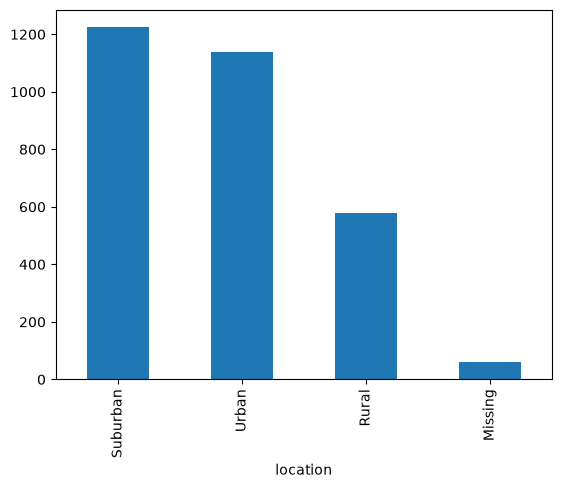

In [547]:
x_train["location"].value_counts(),df["location"].value_counts().plot(kind = "bar") 

In [548]:
x_train.head(),x_test.head()

(      area_sqft  bedrooms  bathrooms  floors garage  distance_from_city_km  \
 2370       1598         3        3.0     2.0    2.0                   17.9   
 1774       1909         5        4.0     1.0    1.0                   13.9   
 731        3569         6        4.0     3.0    2.0                   11.1   
 271        1636         3        2.0     2.0    2.0                   23.0   
 1077        888         2        2.0     1.0    1.0                   20.0   
 
       condition  location  has_garden  has_pool  parking  year_built  
 2370        1.0     Urban           0         0        1        1991  
 1774        1.0  Suburban           1         0        1        1987  
 731         1.0  Suburban           1         0        1        1987  
 271         2.0  Suburban           0         0        0        2004  
 1077        2.0  Suburban           0         0        1        2017  ,
       area_sqft  bedrooms  bathrooms  floors garage  distance_from_city_km  \
 311        

In [549]:
# Apply Encoding to remove categorical data and convert in numerical 
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Missing', 'Rural', 'Urban', 'Suburban']])

oe.fit(x_train[["location"]])

x_train["location"] = oe.transform(x_train[["location"]])
x_test["location"] = oe.transform(x_test[["location"]])

In [550]:
x_train.isnull().sum()

area_sqft                0
bedrooms                 0
bathrooms                0
floors                   0
garage                   0
distance_from_city_km    0
condition                0
location                 0
has_garden               0
has_pool                 0
parking                  0
year_built               0
dtype: int64

In [551]:
x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)

In [552]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [553]:
x_train

,area_sqft,bedrooms,bathrooms,floors,garage,distance_from_city_km,condition,location,has_garden,has_pool,parking,year_built
2370,1598,3,3.0,2.0,2.0,17.9,1.0,2.0,0,0,1,1991
1774,1909,5,4.0,1.0,1.0,13.9,1.0,3.0,1,0,1,1987
731,3569,6,4.0,3.0,2.0,11.1,1.0,3.0,1,0,1,1987
271,1636,3,2.0,2.0,2.0,23.0,2.0,3.0,0,0,0,2004
1077,888,2,2.0,1.0,1.0,20.0,2.0,3.0,0,0,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...
763,3210,4,3.0,1.5,2.0,28.0,2.0,1.0,0,0,0,2001
835,3580,6,4.0,2.0,1.0,18.5,5.0,3.0,1,0,1,1999
1653,2224,3,2.0,2.0,1.0,18.4,1.0,3.0,1,0,1,1984
2607,2237,5,4.0,2.5,1.0,17.9,1.0,2.0,0,0,1,1985


In [554]:
ss.fit(x_train)
x_train[["area_sqft","bedrooms","bathrooms","floors","garage","distance_from_city_km","condition","location","has_garden","has_pool","parking","year_built"]] = ss.transform(x_train)
x_test[["area_sqft","bedrooms","bathrooms","floors","garage","distance_from_city_km","condition","location","has_garden","has_pool","parking","year_built"]] = ss.transform(x_test)

In [555]:
x_train

,area_sqft,bedrooms,bathrooms,floors,garage,distance_from_city_km,condition,location,has_garden,has_pool,parking,year_built
2370,-0.807916,-0.460094,0.201043,0.413426,0.837158,0.272123,-1.460978,-0.231583,-1.311903,-0.460566,0.581199,-0.679820
1774,-0.538096,0.690142,1.106303,-1.113070,-0.358782,-0.204024,-1.460978,1.017405,0.762252,-0.460566,0.581199,-0.950071
731,0.902104,1.265260,1.106303,1.939923,0.837158,-0.537326,-1.460978,1.017405,0.762252,-0.460566,0.581199,-0.950071
271,-0.774948,-0.460094,-0.704217,0.413426,0.837158,0.879209,-0.758585,1.017405,-1.311903,-0.460566,-1.720580,0.198493
1077,-1.423905,-1.035212,-0.704217,-1.113070,-0.358782,0.522100,-0.758585,1.017405,-1.311903,-0.460566,0.581199,1.076807
...,...,...,...,...,...,...,...,...,...,...,...,...
763,0.590639,0.115024,0.201043,-0.349822,0.837158,1.474393,-0.758585,-1.480571,-1.311903,-0.460566,-1.720580,-0.004195
835,0.911647,1.265260,1.106303,0.413426,-0.358782,0.343545,1.348595,1.017405,0.762252,-0.460566,0.581199,-0.139320
1653,-0.264805,-0.460094,-0.704217,0.413426,-0.358782,0.331641,-1.460978,1.017405,0.762252,-0.460566,0.581199,-1.152758
2607,-0.253526,0.690142,1.106303,1.176674,-0.358782,0.272123,-1.460978,-0.231583,-1.311903,-0.460566,0.581199,-1.085196


In [556]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [557]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[13272927.84, 1257555.27, 388214.09,..., 438301.82, 128135.6 , 1022584.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['area_sqft','bedrooms','bathrooms',...,'has_pool','parking','year_built']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.635e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [558]:
y_pred = pd.DataFrame(lr.predict(x_test))

In [559]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE       : ",mean_absolute_error(y_test,y_pred))
print("MSE       : ",mean_squared_error(y_test,y_pred))
print("R2-Score  : ",r2_score(y_test,y_pred))

MAE       :  1554227.9342001413
MSE       :  3693798310030.394
R2-Score  :  0.9828633008478189


In [560]:
from sklearn.linear_model import Ridge
r = Ridge(alpha = 15)

In [561]:
r.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",15
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [562]:
y_pred = pd.DataFrame(r.predict(x_test))

In [563]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE       : ",mean_absolute_error(y_test,y_pred))
print("MSE       : ",mean_squared_error(y_test,y_pred))
print("R2-Score  : ",r2_score(y_test,y_pred))

MAE       :  1549559.8337291335
MSE       :  3668453649925.4487
R2-Score  :  0.982980882745605
